In [1]:
import json
import logging
import math
import os
from functools import partial
from typing import Any, Literal, Optional
import random
import matplotlib.pyplot as plt
import numpy as np
import porepy as pp
import sympy
from scipy import interpolate
from buckley_leverett import (
    analytical_solution,
    functions,
    grid,
    misc,
    numerical_solution,
)

import torch
from torch.utils.data import DataLoader

from tpf_lab.models.buckley_leverett import BuckleyLeverett
from tpf_lab.models.run_models import run_time_dependent_model
from tpf_lab.numerics.ad.functions import ad_pow, minimum
from tpf_lab.utils import logging_redirect_tqdm
from tpf_lab.visualization.diagnostics import DiagnosticsMixin_with_save_functionality
from tpf_lab.ml.nn import BaseNN
from tpf_lab.ml.datasets import DatasetWithNoise
from tpf_lab.ml.train import train
from tpf_lab.ml.nn_ad import nn_wrapper

# Fix seed for reproducability.
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.use_deterministic_algorithms(True)

# Setup logging.
logger = logging.getLogger()
logger.setLevel(logging.INFO)

#### Introduction
In this notebook, we implement a homotopy continuation as introduced in [...]. We use
the homotopy continuation to enable a smooth transition from a linear relative
permeability function to a (potentially) highly oscillating machine learned relative permeability.

#### Governing equations
We employ a two phase flow model in the nonwetting pressure - wetting saturation
formulation. The governing equations are
$$\begin{align*}\\
	\nabla\cdot\mathbf{u} = \nabla\cdot\left(-\lambda_{t}\nabla p_{n} + \lambda_{w}\nabla p_{c} + \lambda_{w}\nabla\rho_{w}\mathbf{g} + \lambda_{n}\nabla\rho_{n}\mathbf{g}\right) & = q_{t}, \\
	\phi\frac{\partial S_{w}}{\partial t} + \nabla\cdot\left(f_{w}\mathbf{u} + f_{w}\lambda_{n}\nabla(p_{c} + \Delta\rho\mathbf{g})\right) & = q_{w}.
\end{align*}$$
Here, $$f_w = \frac{\lambda_w}{\lambda_w + \lambda_n},\quad\lambda_l = \frac{k_{r,l}}{\mu_l}$$ is the fractional wetting flow.

The relative phase mobilities are given by neural networks: $$k_{r,l}(S_w) = \mathcal{N}_l(S_w;\theta).$$

#### Machine learning model
We train a neural network to model wetting phase relative permeabilities. To get some
data, we choose the Brooks-Corey-Burdine model with the parameters $n_1=2,n_2=3,n_3=1$
and perturbate the relative permeabilities with a normal distribution
$$k_{r,w}(\hat{S}_w)=\hat{S}_w^{n_1+n_2\cdot n_3}+\mathcal{N}(\mu,\sigma^2).$$

In [6]:
relpermw_nn = BaseNN({"depth": 5, "hidden_size": 10, "final_act": "linear"})
relpermw_data = DatasetWithNoise(model="Brooks-Corey-W", mean=0.3, std=0.1, model_params={"n_1":2 , "n_2": 3, "n_3":1})

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(0)

relpermw_dataloader = DataLoader(relpermw_data, batch_size=64, worker_init_fn=seed_worker,
    generator=g,)

We take a quick look at the dataset:

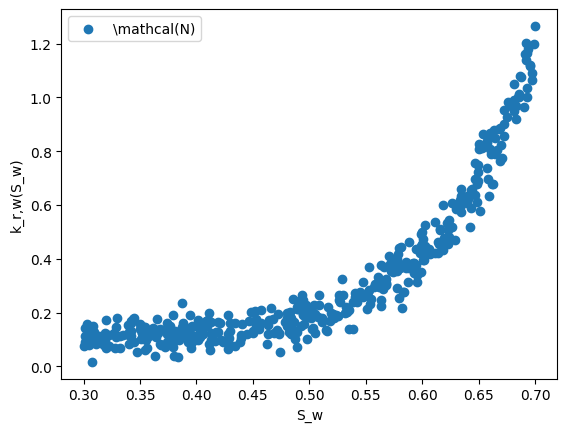

In [12]:
xx = []
yy = []
for x, y in relpermw_data:
    xx.append(x.numpy(force=True))
    yy.append(y.numpy(force=True))
plt.scatter(np.concatenate(xx), np.concatenate(yy), label="\mathcal(N)")
plt.xlabel("S_w")
plt.ylabel("k_r,w(S_w)")
plt.legend()

##### Train the model

In [ ]:
relpermw_trainer = torch.optim.Adam(relpermw_nn.parameters())
train(relpermw_dataloader, relpermw_nn, relpermw_trainer, epochs=1000)

torch.save(relpermw_nn.state_dict(), "test.pt")

#### Homotopy continuation
The wetting relative permeability is given by
$$k_{r,w}(\hat{S_w}) = k\underbrace{c\cdot\hat{S}_w}_{\text{linear rel. perm.}} +
(1-k)\underbrace{\mathcal{N}_w(\hat{S}_w)}_{\text{nn rel. perm.}}.$$

To decay the continuation parameter $k,$ we choose the heuristic update $k_{i+1}=0.5k_i$
inspired by [[Jiang]].

In [ ]:
import numpy as np


class BuckleyLeverett_HomotopyContinuation(BuckleyLeverett):
    def __init__(self, params: dict | None = None) -> None:
        super().__init__(params)
        if params is None:
            params = {}
        # Parameters for the homotopy continuation.
        self._homotopy_continuation_param: float = 1
        # NN rel perm.
        relpermw_nn = BaseNN({"depth": 5, "hidden_size": 10, "final_act": "linear"})
        relpermw_nn.load_state_dict(torch.load("test.pt"))
        self._rel_perm_w_nn_function = pp.ad.Function(nn_wrapper(relpermw_nn), "rel perm w nn")

    def _rel_perm_w_linear(self) -> pp.ad.Operator:
        r"""Linear wetting phase relative permeability."""
        s_normalized = self._s_normalized()
        rel_perm_linear_param = pp.ad.Scalar(self._rel_perm_linear_param)
        rel_perm = s_normalized * rel_perm_linear_param
        if self._limit_rel_perm:
            maximum_func = pp.ad.Function(
                partial(pp.ad.functions.maximum, var_1=self._rel_perm_w_min), "max"
            )
            minimum_func = pp.ad.Function(
                partial(minimum, var_1=self._rel_perm_w_max), "min"
            )
            return minimum_func(maximum_func(rel_perm))
        else:
            return rel_perm

    def _rel_perm_w_nn(self) -> pp.ad.Operator:
        r"""Machine learned wetting phase relative permeability."""
        s_normalized = self._s_normalized()
        rel_perm = self._rel_perm_w_nn_function(s_normalized)
        if self._limit_rel_perm:
            maximum_func = pp.ad.Function(
                partial(pp.ad.functions.maximum, var_1=self._rel_perm_w_min), "max"
            )
            minimum_func = pp.ad.Function(
                partial(minimum, var_1=self._rel_perm_w_max), "min"
            )
            return minimum_func(maximum_func(rel_perm))
        else:
            return rel_perm

    def _rel_perm_w(self) -> pp.ad.Operator:
        r"""Homotopy continuation wetting phase relative permeability."""
        k = pp.ad.Scalar(self._homotopy_continuation_param)
        return k * self._rel_perm_w_nn() + (1 - k) * self._rel_perm_w_linear()

    def _rel_perm_n(self) -> pp.ad.Operator:
        r"""Linear nonwetting phase relative permeability."""
        s_normalized = self._s_normalized()
        rel_perm_linear_param = pp.ad.Scalar(self._rel_perm_linear_param)
        rel_perm = (pp.ad.Scalar(1) - s_normalized) * rel_perm_linear_param
        if self._limit_rel_perm:
            maximum_func = pp.ad.Function(
                partial(pp.ad.functions.maximum, var_1=self._rel_perm_n_min), "max"
            )
            minimum_func = pp.ad.Function(
                partial(minimum, var_1=self._rel_perm_n_max), "min"
            )
            return minimum_func(maximum_func(rel_perm))
        else:
            return rel_perm

    def before_newton_loop(self) -> None:
        # Reset continuation parameter.
        self._homotopy_continuation_param = 1
        return super().before_newton_loop()

    def after_newton_iteration(self, solution: np.ndarray) -> None:
        # Decay continuation parameter.
        self._homotopy_continuation_param *= 0.5
        return super().after_newton_iteration(solution)